# Sprint 7 — Zuber Rideshare Chicago

**Contexto:** Analista de dados da Zuber, empresa de compartilhamento de caronas em Chicago. O objetivo é encontrar padrões nas preferências dos passageiros e testar o impacto do clima nas corridas.

---
# Passo 4 — Análise Exploratória de Dados (Python)

**Objetivo:** Analisar os dados de corridas de táxi em Chicago e identificar padrões nas empresas e nos bairros de destino.

**Etapas:**
- Etapa 1 — Importação das bibliotecas
- Etapa 2 — Importar os CSVs e verificar tipos de dados
- Etapa 3 — Identificar os 10 principais bairros de destino
- Etapa 4 — Gráfico 1: top 15 empresas × número de corridas
- Etapa 5 — Gráfico 2: top 10 bairros por corridas como destino
- Etapa 6 — Conclusões

In [8]:
# Etapa 1: Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# Etapa 2: Importar os CSVs e verificar tipos de dados
data1 = pd.read_csv('/home/luiztrajano75/Sprint-7-coleta-e-armazenamento-de-dados-em-SQL/Sprint-7-projeto-coleta-e-armazenamento-em-SQL/data/moved_project_sql_result_01.csv')
data2 = pd.read_csv('/home/luiztrajano75/Sprint-7-coleta-e-armazenamento-de-dados-em-SQL/Sprint-7-projeto-coleta-e-armazenamento-em-SQL/data/moved_project_sql_result_04.csv')

print('Data1 Types:')
print(data1.dtypes)
print('\nData2 Types:')
print(data2.dtypes)
print()
amostra = data1.sample(n=5)
print('Amostra de Data1:')
print(amostra)
amostra2 = data2.sample(n=5)
print('\nAmostra de Data2:')
print(amostra2)

# Dados limpos e tipos corretos:
# data1 — 64 empresas, trips_amount como int64 ✅
# data2 — 94 bairros, average_trips como float64 ✅
# Nenhum valor nulo nos dois. Dados prontos para análise.
print()
print('Informações de Data1:')
print(data1.info())
print('\nInformações de Data2:')
print(data2.info())

Data1 Types:
company_name    object
trips_amount     int64
dtype: object

Data2 Types:
dropoff_location_name     object
average_trips            float64
dtype: object

Amostra de Data1:
                 company_name  trips_amount
16               Blue Diamond          2070
45  3011 - 66308 JBL Cab Inc.            25
22       Chicago Independents          1296
41       Chicago Star Taxicab            29
15   Checker Taxi Affiliation          2216

Amostra de Data2:
    dropoff_location_name  average_trips
6              Grant Park    2068.533333
49  Sauganash,Forest Glen      43.566667
57                Hermosa      27.566667
16           Logan Square     620.333333
0                    Loop   10727.466667

Informações de Data1:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null    

In [10]:
# Etapa 3: Identificar os 10 principais bairros de destino
top10 = data2.sort_values(by='average_trips', ascending=False).head(10)
print('Os 10 principais bairros de destino:')
print(top10)

Os 10 principais bairros de destino:
  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


/tmp/ipykernel_12246/1058525993.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='company_name', y='trips_amount', data=top15, palette='viridis')


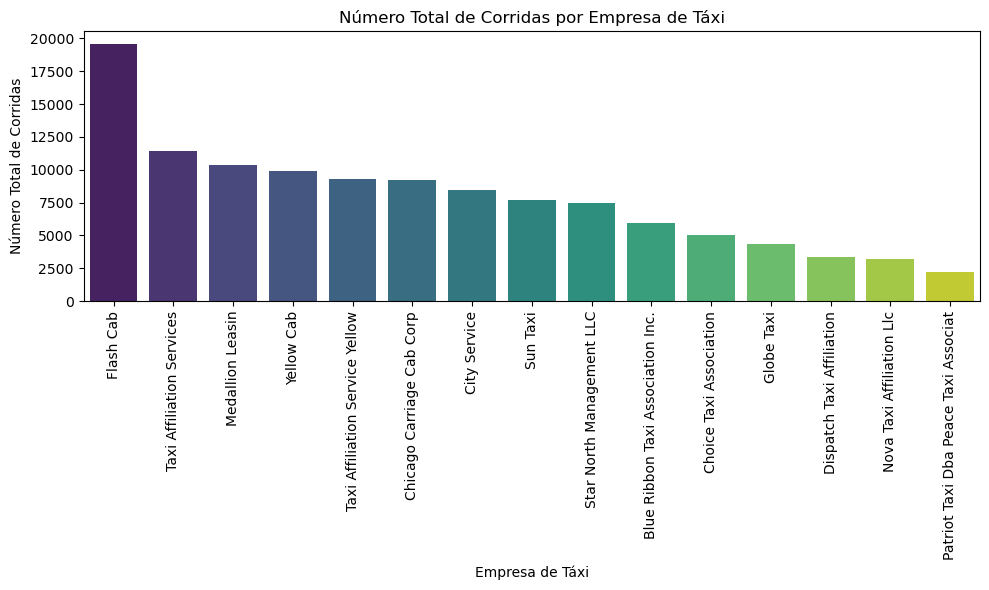

In [11]:
# Etapa 4: Gráfico 1 — top 15 empresas de táxi x número de corridas
top15 = data1.sort_values('trips_amount', ascending=False).head(15)
plt.figure(figsize=(10, 6))
sns.barplot(x='company_name', y='trips_amount', data=top15, palette='viridis')
plt.title('Número Total de Corridas por Empresa de Táxi')
plt.xlabel('Empresa de Táxi')
plt.ylabel('Número Total de Corridas')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

/tmp/ipykernel_12246/2710277859.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='dropoff_location_name', y='average_trips', data=top10, palette='magma')


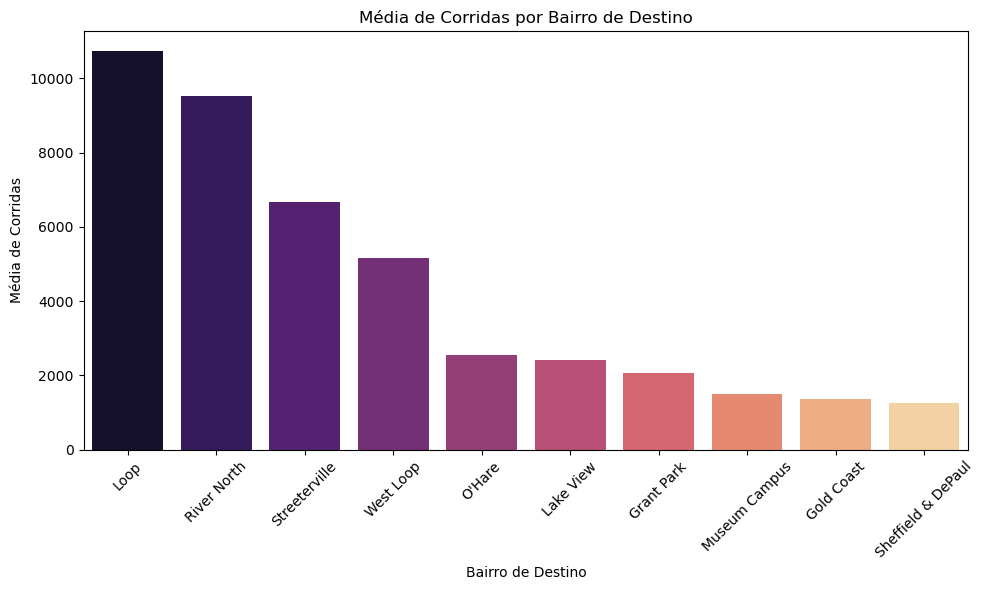

In [12]:
# Etapa 5: Gráfico 2 — top 10 bairros por corridas como destino
plt.figure(figsize=(10, 6))
sns.barplot(x='dropoff_location_name', y='average_trips', data=top10, palette='magma')
plt.title('Média de Corridas por Bairro de Destino')
plt.xlabel('Bairro de Destino')
plt.ylabel('Média de Corridas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Etapa 6 — Conclusões

**Gráfico 1 — Empresas de táxi:**

De acordo com o gráfico plotado, pude avaliar que a Flash Cab domina o mercado com certa folga em relação à Taxi Affiliation Services (top 2), quase que com o dobro do total de viagens como exposto. Ainda assim, algo interessante é visto até o último colocado do top 15: temos reduções de um para outro sem tantas disparidades, o que pode indicar um mercado oligopolizado (poucos grandes) com seu 'campeão' fora da curva.

**Gráfico 2 — Top 10 bairros de destino:**

Fiz uma pesquisa externa extra para entender melhor os bairros presentes. O primeiro e o segundo colocados têm altos números por se tratarem de bairros centrais e turísticos: Loop é um vibrante centro financeiro e cultural de Chicago, famoso pelo circuito elevado de trens ("L") que forma um "loop" oval, com atrações como o Millennium Park (The Bean) e Grant Park. Já River North conta com uma vastidão de restaurantes, galerias e vida noturna, sendo extremamente movimentado também. Vale ressaltar que o quinto lugar (O'Hare) tem número considerável por se tratar de uma área predominantemente residencial que circunda o movimentado Aeroporto Internacional O'Hare (ORD).

---
# Passo 5 — Teste de Hipótese (Python)

**Hipótese:** "A duração média das corridas do Loop ao Aeroporto O'Hare muda nos sábados chuvosos."

**Etapas:**
- Etapa 1 — Importação das bibliotecas
- Etapa 2 — Importar o CSV e verificar os dados
- Etapa 3 — Definir alfa e formular H0 e H1
- Etapa 4 — Separar os grupos Bad e Good
- Etapa 5 — Escolher e justificar o teste estatístico
- Etapa 6 — Executar o teste
- Etapa 7 — Conclusão

In [13]:
# Etapa 1: Importação das bibliotecas
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

In [14]:
# Etapa 2: Importar o CSV e verificar os dados
data7 = pd.read_csv('/home/luiztrajano75/Sprint-7-coleta-e-armazenamento-de-dados-em-SQL/Sprint-7-projeto-coleta-e-armazenamento-em-SQL/data/moved_project_sql_result_07.csv')
data7['start_ts'] = pd.to_datetime(data7['start_ts'])  # corrigindo tipo para datetime
print(data7.info())
print()
print(data7.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   start_ts            1068 non-null   datetime64[ns]
 1   weather_conditions  1068 non-null   object        
 2   duration_seconds    1068 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 25.2+ KB
None

             start_ts weather_conditions  duration_seconds
0 2017-11-25 16:00:00               Good            2410.0
1 2017-11-25 14:00:00               Good            1920.0
2 2017-11-25 12:00:00               Good            1543.0
3 2017-11-04 10:00:00               Good            2512.0
4 2017-11-11 07:00:00               Good            1440.0


## Etapa 3 — Hipóteses e nível de significância

**Nível de significância (alfa):** Vou usar o padrão de 0.05

**H0 (hipótese nula):** Tendo em mente a hipótese em questão, a nula seria que a duração média das corridas em dias de mau tempo ("Bad") é igual à duração média em dias de bom tempo ("Good") — ou seja, o clima não afeta a duração.

**H1 (hipótese alternativa):** Já em contrapartida, a alternativa seria que a duração média das corridas em dias de mau tempo ("Bad") é diferente da duração em dias de bom tempo ("Good") — ou seja, o clima afeta a duração.

In [15]:
# Etapa 4: Separar os grupos Bad e Good
bad = data7[data7['weather_conditions'] == 'Bad']['duration_seconds']
good = data7[data7['weather_conditions'] == 'Good']['duration_seconds']

print("Número de amostras 'Bad':", len(bad))
print()
print("Número de amostras 'Good':", len(good))

Número de amostras 'Bad': 180

Número de amostras 'Good': 888


## Etapa 5 — Escolha e justificativa do teste estatístico

Vou escolher o teste t de Student para amostras independentes, pois o objetivo é comparar as médias de duração entre dois grupos independentes (Bad e Good). As amostras são suficientemente grandes e de tamanhos diferentes, e o teste t é robusto para este caso.

<Figure size 800x600 with 0 Axes>

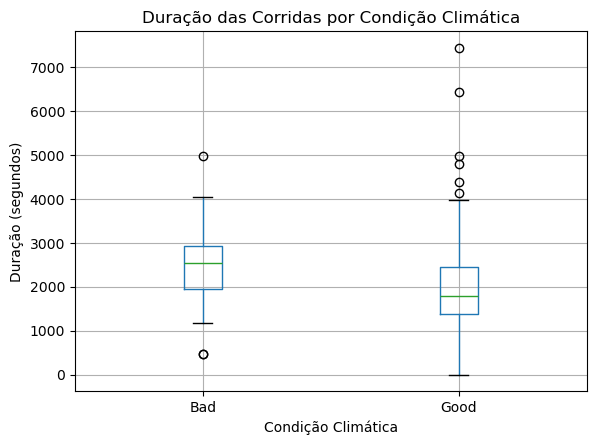

Variância Bad: 520294.08600248274
Variância Good: 576382.0096895089
Variâncias iguais: False


In [18]:
# Etapa 6: Executar o teste e visualizar

# Boxplot para visualizar a distribuição dos dados
plt.figure(figsize=(8, 6))
data7.boxplot(column='duration_seconds', by='weather_conditions')
plt.title('Duração das Corridas por Condição Climática')
plt.suptitle('')
plt.xlabel('Condição Climática')
plt.ylabel('Duração (segundos)')
plt.show()

# Teste t de Student para amostras independentes
# Verificar se as variâncias são iguais
print('Variância Bad:', bad.var())
print('Variância Good:', good.var())
print('Variâncias iguais:', bad.var() == good.var())


In [17]:
# Se as variâncias forem iguais → equal_var=True, senão → equal_var=False
stat, p_value = stats.ttest_ind(bad, good, equal_var=False)
print('Estatística t:', stat)
print('p-value:', p_value)

if p_value < 0.05:
    print("Rejeitamos a hipótese nula: há uma diferença significativa entre os grupos 'Bad' e 'Good'")
else:
    print("Não rejeitamos a hipótese nula: não há uma diferença significativa entre os grupos 'Bad' e 'Good'")

Estatística t: 7.186034288068629
p-value: 6.738994326108735e-12
Rejeitamos a hipótese nula: há uma diferença significativa entre os grupos 'Bad' e 'Good'


## Etapa 7 — Conclusão

### Resultado do Teste Estatístico

Antes de executar o teste, verifiquei as variâncias das amostras:
- **Variância Bad:** 520.294 | **Variância Good:** 576.382 → variâncias **diferentes**

Por isso utilizei `equal_var=False`, que aplica o **Teste de Welch** — variante do teste t mais adequada quando as variâncias dos grupos são desiguais, pois ajusta os graus de liberdade e garante um resultado estatisticamente mais confiável.

- **p-value = 6.74e-12** → extremamente menor que alfa (0.05)
- **Conclusão: rejeito H0**

Há evidência estatística forte de que o clima afeta a duração das corridas do Loop ao O'Hare nos sábados. A hipótese alternativa (H1) é confirmada.

---

### Análise Visual — Boxplot

**1. Tendência Central (Mediana)**
A mediana é visivelmente mais alta em dias de clima ruim (Bad) — ultrapassa 2500 segundos, enquanto em dias Good fica abaixo de 2000 segundos.

**2. Dispersão e Variabilidade**
A caixa de Bad está em um patamar superior e mais concentrado. A caixa de Good é mais ampla, indicando maior variação na duração, mas com a maioria das corridas mais rápidas.

**3. Outliers**
Ambos os grupos apresentam outliers. Em Good, chegam a ultrapassar 7000 segundos — possivelmente engarrafamentos ou eventos excepcionais em dias de trânsito teoricamente fluido.

---

### Conclusão Prática para a Zuber

O clima é uma variável relevante para a operação. Em sábados chuvosos, as corridas do Loop ao O'Hare duram significativamente mais, o que impacta diretamente o planejamento de frotas, estimativa de tempo de chegada e precificação dinâmica. Considerar a condição climática como fator preditivo pode melhorar a experiência do passageiro e a eficiência operacional da empresa.